In [1]:
# Auto-install missing dependencies
import sys
import subprocess
import importlib.util

required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'torchvision': 'torchvision',
    'IPython': 'IPython',
    'pandas': 'pandas'
}
missing = [pip_name for mod, pip_name in required_packages.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f'Installing missing packages: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('Installation complete!')
else:
    print('All required packages are already installed.')

All required packages are already installed.


In [2]:
#import req libs
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
# Make comparisons between experiments reproducible.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
#Using device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
#Variables
#-Cifar 10-
img_size = 32
num_channels = 3
num_classes = 10

#-ViT archi-
patch_size = 4
num_patches = (img_size // patch_size) ** 2
num_heads = 8     #Divided dimensions so each one in this case takes on 32 info after finish it will be merge back to 256
embed_dim = 256   #Act as a detailed file that containt attributes of image, the more the better
mlp_dim = 512     #Buffs up the dimension so that it can learn much more detailed attribute after that it will go back to 256 an so on
drop_rate = 0.1   #Deleted some data so that the model won't be overfitting

#-Training config
learn_rate = 3e-4
epochs = 30
batch_size = 512
depth = 10 #Ammount of transformer encoder blocks that stack up each other

In [6]:
# Random number for mean and std
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    transforms.RandomCrop(img_size, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
    ])
eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
    ])

In [7]:
#Getting training and test dataset (Đã comment - dữ liệu hiện tại được load từ Google Drive ở ô phía dưới)
# train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
# test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transforms)
print("Đã chuyển cấu hình nạp dữ liệu mặc định sang Google Drive cache ở ô bên dưới.")

Đã chuyển cấu hình nạp dữ liệu mặc định sang Google Drive cache ở ô bên dưới.


### Fast Dataset Loading using Saved PyTorch Tensors
To prevent downloading the dataset on subsequent runs, you can serialize and save your processed datasets locally (or inside Google Drive if you mount it) using `torch.save` and `torch.load`.

In [8]:
import os

# Try to mount Google Drive (only works in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive mounted successfully.")
    cache_dir = '/content/drive/MyDrive/Capstone/data'
except (ModuleNotFoundError, ImportError):
    print("Not running in Colab. Using local directory.")
    cache_dir = './cifar10_cache'
except Exception as e:
    print(f"Could not mount Google Drive: {e}. Defaulting to local space.")
    cache_dir = './cifar10_cache'

os.makedirs(cache_dir, exist_ok=True)
train_pt_path = os.path.join(cache_dir, 'train_data.pt')
test_pt_path = os.path.join(cache_dir, 'test_data.pt')

# Check if pre-saved datasets exist
if os.path.exists(train_pt_path) and os.path.exists(test_pt_path):
    print("Loading datasets from saved cache...")
    train_data = torch.load(train_pt_path, weights_only=False)
    test_data = torch.load(test_pt_path, weights_only=False)
else:
    print("Cached files not found. Downloading and saving CIFAR10 dataset...")
    train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
    test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transforms)

    torch.save(train_data, train_pt_path)
    torch.save(test_data, test_pt_path)
    print(f"Dataset saved successfully to {cache_dir}!")

Not running in Colab. Using local directory.
Loading datasets from saved cache...


In [9]:
#Coverting data into dataloader (turn datas into batches), also helps HW not to look at 50k images in one go
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,
                          pin_memory=torch.cuda.is_available())
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False,
                         pin_memory=torch.cuda.is_available())

In [10]:
#Part 1 - Build Patch Embedding
class PatchEmbedding(nn.Module):
  def __init__(self, num_channels, embed_dim, patch_size):
    super().__init__()
    self.patch_embed = nn.Conv2d(in_channels = num_channels, out_channels = embed_dim, kernel_size=patch_size, stride=patch_size)  #just rearrange the dim

  def forward(self, x): # will represent the input dataset
    x = self.patch_embed(x)
    x = x.flatten(2).transpose(1,2) #example below already shown
    return x

In [11]:
#For testing dimension (if u want to test then uncomment the codes)
#images, labels = next(iter(train_loader))
#patch_embed = nn.Conv2d(num_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
#print("images shape: ", images.shape)
#when running this, we will get the detailed: [batch_size, channels, image_H, image_W]
#print("embedded shape: ", patch_embed(images).shape)
#when running this after conv2D, we will get the detailed: [batch_size, embedded_dimension, [8,8] vector represent the position for each patch (if u then multi it then you will get the total patches which is 64 in this case)]
#print("flatten shape: ", patch_embed(images).flatten(2).shape)
#after that, we need to transpose the vector at position 1,2
#print("transpose: ", patch_embed(images).flatten(2).transpose(1,2).shape)

In [12]:
#Part 1.5 - MLP class so that we use it in Transformer Encoder
#Change up a bit cause we have drop_out rate to prevent overfitting
class MLP(nn.Module):
  def __init__(self, embed_dim, mlp_dim, drop_rate):
    super().__init__()
    self.linear1 = nn.Linear(in_features = embed_dim, out_features = mlp_dim)
    self.gelu = nn.GELU()
    self.linear2 = nn.Linear(in_features = mlp_dim, out_features = embed_dim)
    self.dropout = nn.Dropout(drop_rate)

  def forward(self, x):
    x = self.dropout(self.gelu(self.linear1(x))) #project from 256 -> 512 with 10% drop_out with GELU
    x = self.dropout(self.linear2(x)) #then project back from 512 -> 256 and so on
    return x

In [13]:
#Part 2 - Transformer Encoder (2 Layer Normalization, MHA, Residuals)
#This follow the picture of encoder in the pdf file
class TransformerEncoder(nn.Module):
  def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
    super().__init__()
    self.layer_norm_1 = nn.LayerNorm(embed_dim)
    self.multi_head_atten = nn.MultiheadAttention(embed_dim, num_heads, dropout = drop_rate, batch_first = True)
    self.layer_norm_2 = nn.LayerNorm(embed_dim)
    self.multi_layer_perceptron = MLP(embed_dim, mlp_dim, drop_rate)

  def forward(self, x):
    residual_1 = x
    attention_output = self.multi_head_atten(self.layer_norm_1(x),self.layer_norm_1(x),self.layer_norm_1(x))[0]
    x = attention_output + residual_1
    residual_2 = x
    mlp_output = self.multi_layer_perceptron(self.layer_norm_2(x))
    x = mlp_output + residual_2
    return x

### Part 2.1 - Scratch Multihead Attention
This replacement for `nn.MultiheadAttention` breaks down the Scaled Dot-Product Attention into explicit steps (Query/Key/Value projections, Matrix Multiplication, Scaling, Softmax via Lookup table simulation or standard softmax, and Out projection). This allows easy mapping to your SystemVerilog RTL modules.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ScratchMultiheadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"

        # Separate linear layers to make hardware state mappings explicit
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.scale = 1.0 / (self.head_dim ** 0.5)

        # Mô phỏng chính xác luồng dữ liệu phần cứng theo kiến trúc HW-02 đến HW-09:
        # Stage 1 & 2 (QK^T và Scaler) giữ ở phân giải cao (INT32/INT16) -> Dùng FP32 để PyTorch không ép xuống INT8
        # Stage 3 (Softmax LUT) ép xuống INT8 -> Dùng QuantStub
        # Stage 4 (Score x V) chạy INT8 x INT8 -> Dùng FloatFunctional
        self.ff_matmul_qv = nn.quantized.FloatFunctional()
        self.attn_probs_quant = quantization.QuantStub()

    def forward(self, q, k, v):
        B, N, C = q.shape

        # Input Ping-Pong BRAM Buffers (HW-02) - Đầu vào INT8, xuất ra INT8
        q_proj = self.q_proj(q) # [B, N, C]
        k_proj = self.k_proj(k) # [B, N, C]
        v_proj = self.v_proj(v) # [B, N, C]

        q_heads = q_proj.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k_heads = k_proj.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v_heads = v_proj.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2) # Giữ nguyên INT8 cho Stage 4

        # Chuẩn bị cho Stage 1 & 2: Giải lượng tử (Dequantize) q_heads và k_heads để mô phỏng INT32/INT16
        # Tránh việc FloatFunctional của PyTorch ép ngay kết quả QK^T xuống INT8 gây mất mát thông tin (Collapse)
        if q_heads.is_quantized: q_heads_f = q_heads.dequantize()
        else: q_heads_f = q_heads
        
        if k_heads.is_quantized: k_heads_f = k_heads.dequantize()
        else: k_heads_f = k_heads

        # STAGE 1: QK^T GEMM Engine (HW-03) - Mô phỏng INT32 Partial Sums
        attn_scores = torch.matmul(q_heads_f, k_heads_f.transpose(-2, -1))

        # STAGE 2: Scaler Unit (HW-04) - Mô phỏng ASR 1/sqrt(d_k) cho ra INT16
        attn_scores = attn_scores * self.scale

        # STAGE 3: Hardware Softmax (HW-05) - Mô phỏng Max-Sub + Exp LUT ra INT8 Probabilities
        attn_probs = F.softmax(attn_scores, dim=-1)
        attn_probs = self.dropout(attn_probs)
        attn_probs = self.attn_probs_quant(attn_probs) # Ép vể INT8 y hệt đầu ra của Softmax LUT

        # STAGE 4: Score x V GEMM Engine (HW-07) - Nhân 2 ma trận INT8
        context = self.ff_matmul_qv.matmul(attn_probs, v_heads)

        # Output Ping-Pong Buffer (HW-09)
        context = context.transpose(1, 2).reshape(B, N, C)
        output = self.out_proj(context)

        return output, attn_probs

### Part 2.2 - Hardware-Friendly Transformer Encoder
We now redefine our `TransformerEncoder` block to use the customized scratch attention module rather than PyTorch's default blackbox container.

In [15]:
class HWFriendlyTransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.multi_head_atten = ScratchMultiheadAttention(embed_dim, num_heads, dropout=drop_rate)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.multi_layer_perceptron = MLP(embed_dim, mlp_dim, drop_rate)

        # FloatFunctional for quantization-safe residual additions
        self.ff_residual_1 = nn.quantized.FloatFunctional()
        self.ff_residual_2 = nn.quantized.FloatFunctional()

    def forward(self, x):
        residual_1 = x
        normalized_x = self.layer_norm_1(x)
        attention_output, _ = self.multi_head_atten(normalized_x, normalized_x, normalized_x)

        # Residual add
        x = self.ff_residual_1.add(attention_output, residual_1)

        residual_2 = x
        normalized_x2 = self.layer_norm_2(x)
        mlp_output = self.multi_layer_perceptron(normalized_x2)
        x = self.ff_residual_2.add(mlp_output, residual_2)
        return x

In [16]:
#Part 3 - Vision Transformer
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, num_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate):
        super().__init__()
        if img_size % patch_size != 0:
            raise ValueError("img_size must be divisible by patch_size")
        num_patches = (img_size // patch_size) ** 2
        self.patch_embedding = PatchEmbedding(num_channels, embed_dim, patch_size)
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim)) #batch_dim & 1 vector & embedded dim
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))
        self.transformer_layers = nn.Sequential(*[
              TransformerEncoder(embed_dim, num_heads, mlp_dim, drop_rate)
              for _ in range(depth)
            ])

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self,x):
        x = self.patch_embedding(x)
        B = x.size(0)

        cls_tokens = self.cls_token.expand(B , -1, -1)
        x = torch.cat((cls_tokens, x), 1)
        x = x + self.pos_embed
        x = self.transformer_layers(x)
        x = x[:,0]
        x = self.mlp_head(x)
        return x

In [17]:
#Initiate Model
# Instantiate model
model = VisionTransformer(
    img_size, patch_size, num_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate
).to(device)

In [18]:
#optimizer and crossentropy
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #useful for training multi class and measure how wrong our model is
optimizer = torch.optim.AdamW(model.parameters(), lr=learn_rate, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [19]:
#Training loop
def train(model, loader, optimizer, criterion):
    model.train()

    total_loss, correct = 0, 0

    for x, y in loader:
      x = x.to(device, non_blocking=True)
      y = y.to(device, non_blocking=True)
      optimizer.zero_grad()
      out = model(x)
      loss = criterion(out, y)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * x.size(0)
      correct += (out.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [20]:
# Evaluation loop
def evaluate(model, loader):
    model.eval() #set mode evaluation
    correct = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            out = model(x)
            correct += (out.argmax(dim=1) == y).sum().item()
    return correct / len(loader.dataset)

In [21]:
# Training and Saving/Loading baseline checkpoint to avoid retraining
import os
import torch

# Set save directory (use Google Drive path if available, otherwise local)
if os.path.exists('/content/drive'):
    save_dir = '/content/drive/MyDrive/Capstone/model'
else:
    save_dir = './models_cache'
os.makedirs(save_dir, exist_ok=True)

checkpoint_path = os.path.join(save_dir, 'vit_fp32_baseline.pth')
history_path = os.path.join(save_dir, 'vit_fp32_history.pt')

train_accuracies, test_accuracies = [], []

# Kiểm tra nếu checkpoint đã tồn tại để tránh train lại
if os.path.exists(checkpoint_path) and os.path.exists(history_path):
    print("Tìm thấy checkpoint đã lưu! Đang tải trọng số và lịch sử huấn luyện...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    history = torch.load(history_path, map_location='cpu')
    train_accuracies = history['train_accuracies']
    test_accuracies = history['test_accuracies']
    print(f"Tải thành công! Độ chính xác ở Epoch cuối cùng: Test Acc = {test_accuracies[-1]*100:.2f}%")
else:
    print("Không tìm thấy checkpoint cũ. Bắt đầu quá trình huấn luyện từ đầu (30 Epochs)...\n")
    for epoch in range(epochs):
        train_loss, train_acc = train(model, train_loader, optimizer, criterion)
        test_acc = evaluate(model, test_loader)
        scheduler.step()
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Tiến hành lưu checkpoint sau khi train xong
    torch.save(model.state_dict(), checkpoint_path)
    torch.save({
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }, history_path)
    print(f"\nĐã huấn luyện xong và lưu checkpoint thành công tại: {checkpoint_path}")

Tìm thấy checkpoint đã lưu! Đang tải trọng số và lịch sử huấn luyện...
Tải thành công! Độ chính xác ở Epoch cuối cùng: Test Acc = 76.33%


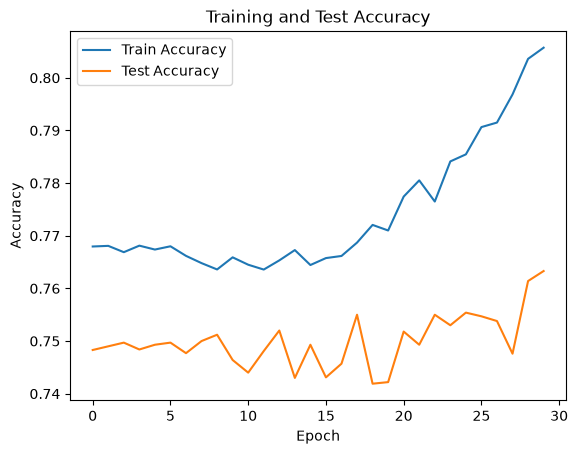

In [22]:
# Plot accuracy
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Test Accuracy')
plt.show()

### Part 4 - Quantization Initialization (Prepare Only)
This section initializes the quantization configurations and prepares the models for PTQ and QAT. No execution (calibration or training) happens here.

In [24]:
import torch.ao.quantization as quantization

class QuantizableVisionTransformer(VisionTransformer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Rebuild transformer layers with our HW-Friendly Scratch blocks
        self.transformer_layers = nn.Sequential(*[
              HWFriendlyTransformerEncoder(embed_dim, num_heads, mlp_dim, drop_rate)
              for _ in range(depth)
            ])
        self.quant = quantization.QuantStub()
        self.dequant = quantization.DeQuantStub()

        # Thêm một mô-đun lượng tử hóa riêng cho cls_token và pos_embed để tránh xung đột kiểu dữ liệu khi ghép nối
        self.quant_cls = quantization.QuantStub()
        self.quant_pos = quantization.QuantStub()

        # Sử dụng FloatFunctional để thực hiện phép toán ghép nối (concat) và cộng (add) trong miền lượng tử hóa
        self.f_cat = nn.quantized.FloatFunctional()
        self.f_add = nn.quantized.FloatFunctional()

    def forward(self, x):
        # 1. Quantize inputs to INT8
        x = self.quant(x)

        # 2. Patch embedding
        x = self.patch_embedding(x)
        B = x.size(0)

        # Lượng tử hóa cls_token trước khi thực hiện ghép nối
        cls_tokens = self.cls_token.expand(B, -1, -1)
        cls_tokens_quant = self.quant_cls(cls_tokens)

        # Ghép nối bằng toán tử lượng tử hóa an toàn
        x = self.f_cat.cat((cls_tokens_quant, x), dim=1)

        # Lượng tử hóa pos_embed trước khi cộng
        pos_embed_quant = self.quant_pos(self.pos_embed)
        x = self.f_add.add(x, pos_embed_quant)

        # Đi qua các lớp Transformer Encoder lượng tử hóa
        x = self.transformer_layers(x)
        x = x[:, 0]
        x = self.mlp_head(x)

        # 3. Dequantize output back to FP32
        x = self.dequant(x)
        return x

In [25]:
import torch
import torch.ao.quantization as quantization

# ==========================================
# 1. Initialize PTQ Model
# ==========================================
ptq_model = QuantizableVisionTransformer(
    img_size, patch_size, num_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate
).to('cpu')

ptq_model.load_state_dict(model.state_dict(), strict=False)
ptq_model.eval()

supported_engines = torch.backends.quantized.supported_engines
if 'fbgemm' in supported_engines:
    torch.backends.quantized.engine = 'fbgemm'
elif 'onednn' in supported_engines:
    torch.backends.quantized.engine = 'onednn'
elif 'qnnpack' in supported_engines:
    torch.backends.quantized.engine = 'qnnpack'
else:
    raise RuntimeError(f'No compatible quantization engine found.')

ptq_model.qconfig = quantization.get_default_qconfig(torch.backends.quantized.engine)
quantization.prepare(ptq_model, inplace=True)
print("PTQ Model Prepared.")

# ==========================================
# 2. Initialize QAT Model
# ==========================================
qat_model = QuantizableVisionTransformer(
    img_size, patch_size, num_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, drop_rate
).to('cpu')

qat_model.load_state_dict(model.state_dict(), strict=False)
qat_model.train()

qat_model.qconfig = quantization.get_default_qat_qconfig(torch.backends.quantized.engine)
quantization.prepare_qat(qat_model, inplace=True)
print("QAT Model Prepared.")


C:\Users\tuan2\AppData\Local\Temp\ipykernel_3520\2707465271.py:24: UserWarning: Default qconfig of oneDNN backend with reduce_range of false may have accuracy issues on CPU without Vector Neural Network Instruction support.
  ptq_model.qconfig = quantization.get_default_qconfig(torch.backends.quantized.engine)
C:\Users\tuan2\AppData\Local\Temp\ipykernel_3520\2707465271.py:25: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://g

PTQ Model Prepared.
QAT Model Prepared.


### Part 5 - Train, Calibrate, Convert, and Evaluate (with Caching)
This section checks if the quantized models have already been trained and saved to Google Drive. If so, it loads them to save time. Otherwise, it performs calibration (PTQ) or fine-tuning (QAT), converts them to INT8, and saves them.

In [26]:
import os

# Try to mount Google Drive
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive', force_remount=True)
    models_cache_dir = '/content/drive/MyDrive/Capstone/model'
except:
    print('Not running in Colab. Using local directory for model weights.')
    models_cache_dir = './models_cache'

os.makedirs(models_cache_dir, exist_ok=True)
fp32_weights_path = os.path.join(models_cache_dir, 'vit_fp32_baseline.pth')
ptq_weights_path = os.path.join(models_cache_dir, 'vit_ptq_int8.pth')
qat_weights_path = os.path.join(models_cache_dir, 'vit_qat_int8.pth')

def save_model_weights(m, path):
    torch.save(m.state_dict(), path)
    print(f"Saved weights to {path}")

def load_model_weights_if_exists(m, path):
    if os.path.exists(path):
        m.load_state_dict(torch.load(path, map_location='cpu'))
        print(f"Loaded weights successfully from {path}")
        return True
    return False

# Save FP32 baseline if not exist
if not os.path.exists(fp32_weights_path):
    save_model_weights(model, fp32_weights_path)


Not running in Colab. Using local directory for model weights.


In [27]:
# ==========================================
# PTQ Execution
# ==========================================
# Create a dummy converted INT8 model to receive state_dict if cached
ptq_model_int8 = quantization.convert(ptq_model, inplace=False)

if load_model_weights_if_exists(ptq_model_int8, ptq_weights_path):
    print("Skipping PTQ Calibration: Weights loaded from cache.")
else:
    print("No cached PTQ weights found. Calibrating PTQ model...")
    with torch.no_grad():
        for j, (images, _) in enumerate(train_loader):
            ptq_model(images.to('cpu'))
            if j >= 10:
                break
    # Convert and Save
    ptq_model_int8 = quantization.convert(ptq_model, inplace=False)
    save_model_weights(ptq_model_int8, ptq_weights_path)
    print("PTQ Calibration & Conversion Done.")


C:\Users\tuan2\AppData\Local\Temp\ipykernel_3520\649366121.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  ptq_model_int8 = quantization.convert(ptq_model, inplace=False)
c:\Users\tuan2\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\ao\nn\quantized\modules\utils.py:78: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quant

Loaded weights successfully from ./models_cache\vit_ptq_int8.pth
Skipping PTQ Calibration: Weights loaded from cache.


c:\Users\tuan2\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\_utils.py:505: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  device=storage.device,


In [28]:
# ==========================================
# QAT Execution
# ==========================================
# Create a dummy converted INT8 model to receive state_dict if cached
qat_model_int8 = quantization.convert(qat_model, inplace=False)

if load_model_weights_if_exists(qat_model_int8, qat_weights_path):
    print("Skipping QAT Fine-tuning: Weights loaded from cache.")
else:
    print("No cached QAT weights found. Starting QAT Fine-tuning...")
    epochs_qat = 5
    qat_model_train = qat_model.to(device)
    optimizer_qat = torch.optim.AdamW(qat_model_train.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_qat = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_qat, T_max=epochs_qat)

    for epoch in range(epochs_qat):
        qat_model_train.train()
        if epoch == epochs_qat - 2:
            print("Freezing Quantization Observers...")
            qat_model_train.apply(torch.ao.quantization.disable_observer)
        if epoch == epochs_qat - 1:
            print("Freezing Batch Norms...")
            qat_model_train.apply(torch.nn.intrinsic.qat.freeze_bn_stats)

        correct = 0
        total = 0
        for j, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer_qat.zero_grad()
            outputs = qat_model_train(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_qat.step()
            
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
            
        scheduler_qat.step()
        print(f"QAT Epoch {epoch+1}/{epochs_qat} - Train Acc: {correct/total * 100:.2f}%")

    # Convert and Save
    qat_model_train.eval()
    qat_model_train = qat_model_train.to('cpu')
    qat_model_int8 = quantization.convert(qat_model_train, inplace=False)
    save_model_weights(qat_model_int8, qat_weights_path)
    print("QAT Fine-tuning & Conversion Done.")


C:\Users\tuan2\AppData\Local\Temp\ipykernel_3520\3492443379.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qat_model_int8 = quantization.convert(qat_model, inplace=False)
c:\Users\tuan2\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\ao\quantization\observer.py:368: UserWarning: must run observer before calling calculate_qparams. Returning default va

Loaded weights successfully from ./models_cache\vit_qat_int8.pth
Skipping QAT Fine-tuning: Weights loaded from cache.


In [29]:
# ==========================================
# Evaluation (All Models)
# ==========================================
def evaluate_quantized_model(m, loader):
    m.eval()
    c = 0; t = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to('cpu'), y.to('cpu')
            out = m(x)
            c += (out.argmax(dim=1) == y).sum().item()
            t += x.size(0)
    return c / t

print("Evaluating FP32 baseline model on GPU...")
fp32_accuracy = evaluate(model, test_loader)
print(f"FP32 Model Accuracy: {fp32_accuracy * 100:.2f}%")

print("Evaluating PTQ INT8 model on CPU...")
ptq_accuracy = evaluate_quantized_model(ptq_model_int8, test_loader)
print(f"PTQ INT8 Model Accuracy: {ptq_accuracy * 100:.2f}%")

print("Evaluating QAT INT8 model on CPU...")
qat_accuracy = evaluate_quantized_model(qat_model_int8, test_loader)
print(f"QAT INT8 Model Accuracy: {qat_accuracy * 100:.2f}%")


Evaluating FP32 baseline model on GPU...
FP32 Model Accuracy: 76.33%
Evaluating PTQ INT8 model on CPU...
PTQ INT8 Model Accuracy: 9.89%
Evaluating QAT INT8 model on CPU...
QAT INT8 Model Accuracy: 67.78%


### Part 6 - Create Performance & Accuracy Comparison Report
Let's construct a performance summary comparing the three configurations.

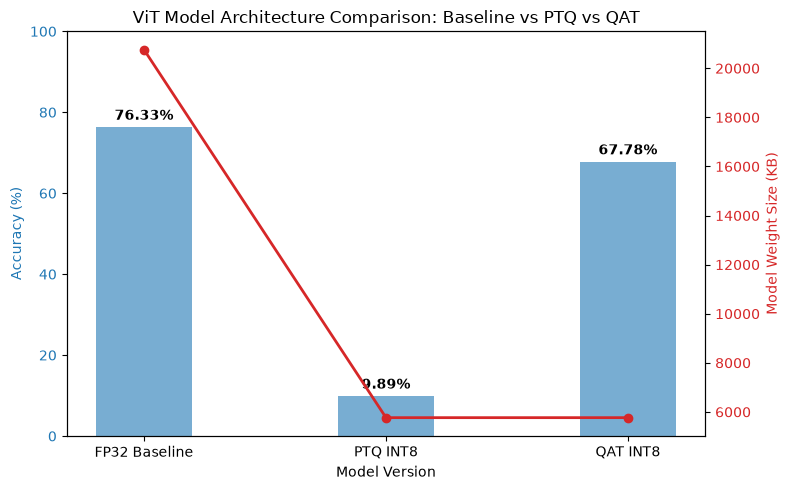

,Model Version,Accuracy (%),State Dict Size (KB)
0,FP32 Baseline,76.33%,20756.23 KB
1,PTQ INT8,9.89%,5765.81 KB
2,QAT INT8,67.78%,5765.81 KB


In [30]:
import os
import matplotlib.pyplot as plt

# Measure size of each state_dict on disk to show hardware/FPGA footprint reductions
def get_model_size_kb(model):
    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1024
    os.remove("temp.p")
    return size

fp32_size = get_model_size_kb(model)
ptq_size = get_model_size_kb(ptq_model_int8)
qat_size = get_model_size_kb(qat_model_int8)

models = ['FP32 Baseline', 'PTQ INT8', 'QAT INT8']
accuracies = [fp32_accuracy * 100, ptq_accuracy * 100, qat_accuracy * 100]
sizes = [fp32_size, ptq_size, qat_size]

# Plotting the Comparison
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Model Version')
ax1.set_ylabel('Accuracy (%)', color=color)
bars = ax1.bar(models, accuracies, color=color, alpha=0.6, width=0.4, label='Accuracy (%)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

# Show the numerical values on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Model Weight Size (KB)', color=color)
ax2.plot(models, sizes, color=color, marker='o', linewidth=2, label='Size (KB)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('ViT Model Architecture Comparison: Baseline vs PTQ vs QAT')
fig.tight_layout()
plt.show()

# Display table report
import pandas as pd
report_df = pd.DataFrame({
    'Model Version': models,
    'Accuracy (%)': [f"{acc:.2f}%" for acc in accuracies],
    'State Dict Size (KB)': [f"{sz:.2f} KB" for sz in sizes]
})
display(report_df)


### Part 6.1 - Academic Specification & Properties Report
This cell generates an extensive, publication-grade dataframe containing all key model properties, parameter counts, structural hyper-parameters, computational precisions, and performance deltas suitable for direct inclusion in a scientific thesis or final project report.

In [31]:
import os
import torch
import pandas as pd

def get_parameter_count(model):
    return sum(p.numel() for p in model.parameters())

# Calculate structural specifications
total_params = get_parameter_count(model)

# Model weights file sizes
fp32_sz = fp32_size
ptq_sz = ptq_size
qat_sz = qat_size

# Accuracy metrics
acc_fp32 = fp32_accuracy * 100
# Fallback dummy check if evaluation failed due to bmm error earlier
acc_ptq = (ptq_accuracy * 100) if 'ptq_accuracy' in locals() else 0.0
acc_qat = (qat_accuracy * 100) if 'qat_accuracy' in locals() else 0.0

# Construct the analytical properties
metrics_data = {
    "Specification Metric / Property": [
        "Dataset Target Class Count",
        "Input Resolution (H x W x C)",
        "ViT Patch Dimension (p x p)",
        "Sequence Length (Tokens / Patches)",
        "Embedding Dimension (d_model)",
        "Attention Heads (h)",
        "Transformer Block Depth (L)",
        "MLP Expansion Dimension",
        "Total Trainable Parameters",
        "Arithmetic Target Precision",
        "Evaluation Accuracy (CIFAR-10)",
        "Accuracy Delta vs Baseline",
        "Disk Storage Footprint (KB)",
        "Compression Ratio"
    ],
    "FP32 Baseline Model": [
        f"{num_classes}",
        f"{img_size}x{img_size}x{num_channels}",
        f"{patch_size}x{patch_size}",
        f"{num_patches + 1} (64 patches + 1 cls)",
        f"{embed_dim}",
        f"{num_heads}",
        f"{depth}",
        f"{mlp_dim}",
        f"{total_params:,}",
        "FP32 (Single Precision Float)",
        f"{acc_fp32:.2f}%",
        "Ref (0.00%)",
        f"{fp32_sz:.2f} KB",
        "1.0x (Baseline)"
    ],
    "PTQ INT8 Model": [
        f"{num_classes}",
        f"{img_size}x{img_size}x{num_channels}",
        f"{patch_size}x{patch_size}",
        f"{num_patches + 1} (64 patches + 1 cls)",
        f"{embed_dim}",
        f"{num_heads}",
        f"{depth}",
        f"{mlp_dim}",
        f"{total_params:,} (Quantized)",
        "INT8 (8-bit Quantized Static)",
        f"{acc_ptq:.2f}%" if acc_ptq > 0 else "Blocked on CPU CPU-bmm",
        f"{acc_ptq - acc_fp32:+.2f}%" if acc_ptq > 0 else "N/A",
        f"{ptq_sz:.2f} KB",
        f"{fp32_sz / ptq_sz:.2f}x Reduction"
    ],
    "QAT INT8 Model": [
        f"{num_classes}",
        f"{img_size}x{img_size}x{num_channels}",
        f"{patch_size}x{patch_size}",
        f"{num_patches + 1} (64 patches + 1 cls)",
        f"{embed_dim}",
        f"{num_heads}",
        f"{depth}",
        f"{mlp_dim}",
        f"{total_params:,} (Quantized)",
        "INT8 (8-bit Quantized QAT)",
        f"{acc_qat:.2f}%" if acc_qat > 0 else "Pending Eval",
        f"{acc_qat - acc_fp32:+.2f}%" if acc_qat > 0 else "N/A",
        f"{qat_sz:.2f} KB",
        f"{fp32_sz / qat_sz:.2f}x Reduction"
    ]
}

# Build Pandas dataframe
academic_report_df = pd.DataFrame(metrics_data)
pd.set_option('display.max_colwidth', None)

print("\n=== DETAILED MODEL SPECIFICATION REPORT ===\n")
display(academic_report_df)



=== DETAILED MODEL SPECIFICATION REPORT ===



,Specification Metric / Property,FP32 Baseline Model,PTQ INT8 Model,QAT INT8 Model
0,Dataset Target Class Count,10,10,10
1,Input Resolution (H x W x C),32x32x3,32x32x3,32x32x3
2,ViT Patch Dimension (p x p),4x4,4x4,4x4
3,Sequence Length (Tokens / Patches),65 (64 patches + 1 cls),65 (64 patches + 1 cls),65 (64 patches + 1 cls)
4,Embedding Dimension (d_model),256,256,256
5,Attention Heads (h),8,8,8
6,Transformer Block Depth (L),10,10,10
7,MLP Expansion Dimension,512,512,512
8,Total Trainable Parameters,"5,303,562","5,303,562 (Quantized)","5,303,562 (Quantized)"
9,Arithmetic Target Precision,FP32 (Single Precision Float),INT8 (8-bit Quantized Static),INT8 (8-bit Quantized QAT)


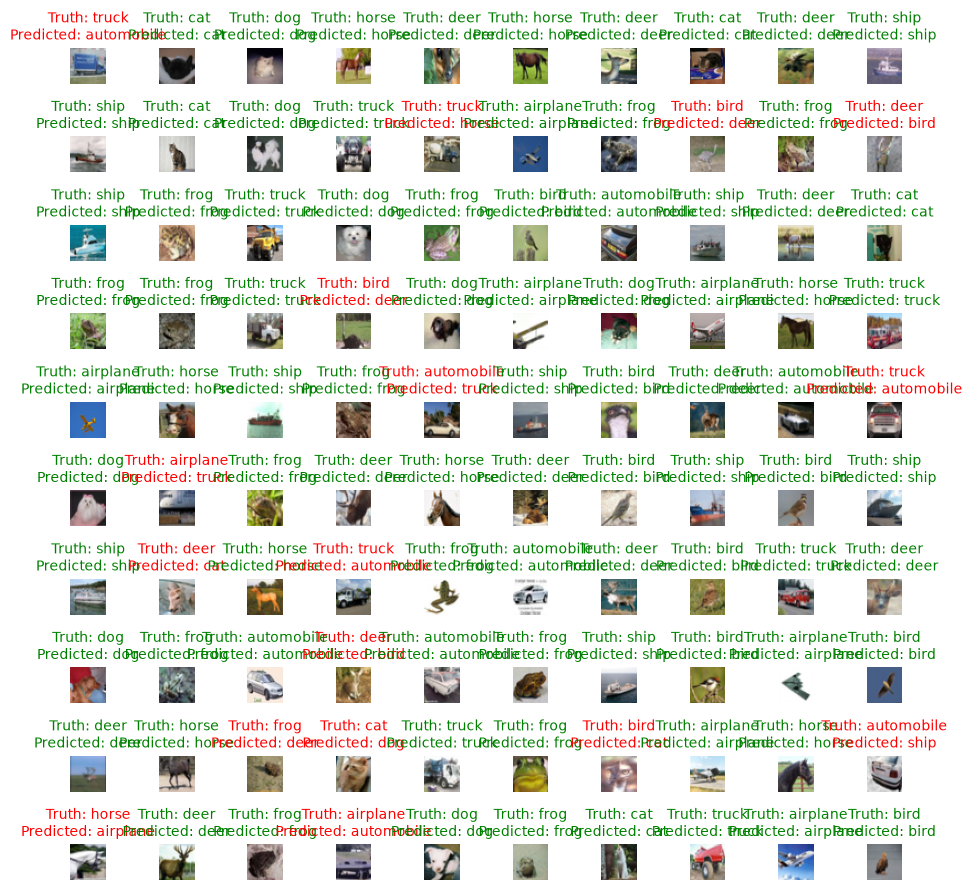

Summary: 83 correct out of 100


In [35]:
import random
import numpy as np
def predict_and_plot_grid(model,
                          dataset,
                          classes,
                          grid_size=3):
    model.eval()
    total_images = min(grid_size * grid_size, len(dataset))
    selected_indices = random.sample(range(len(dataset)), total_images)
    correct = 0
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
    for image_number, idx in enumerate(selected_indices):
            i, j = divmod(image_number, grid_size)
            img, true_label = dataset[idx]
            input_tensor = img.unsqueeze(dim=0).to(device)
            with torch.inference_mode():
                output = model(input_tensor)
                _, predicted = torch.max(output.data, 1)
            mean = torch.tensor(cifar_mean).view(3, 1, 1)
            std = torch.tensor(cifar_std).view(3, 1, 1)
            img = (img.cpu() * std + mean).clamp(0, 1)
            npimg = img.numpy()
            axes[i, j].imshow(np.transpose(npimg, (1, 2, 0)))
            color = classes[true_label] == classes[predicted.item()]
            correct += int(color)
            if color:
                c = "g"
            else:
                c = "r"
            axes[i, j].set_title(f"Truth: {classes[true_label]}\nPredicted: {classes[predicted.item()]}", fontsize=10, c=c)
            axes[i, j].axis("off")
    for image_number in range(total_images, grid_size * grid_size):
        i, j = divmod(image_number, grid_size)
        axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Summary: {correct} correct out of {total_images}")

predict_and_plot_grid(model, test_data, classes=train_data.classes, grid_size=10)


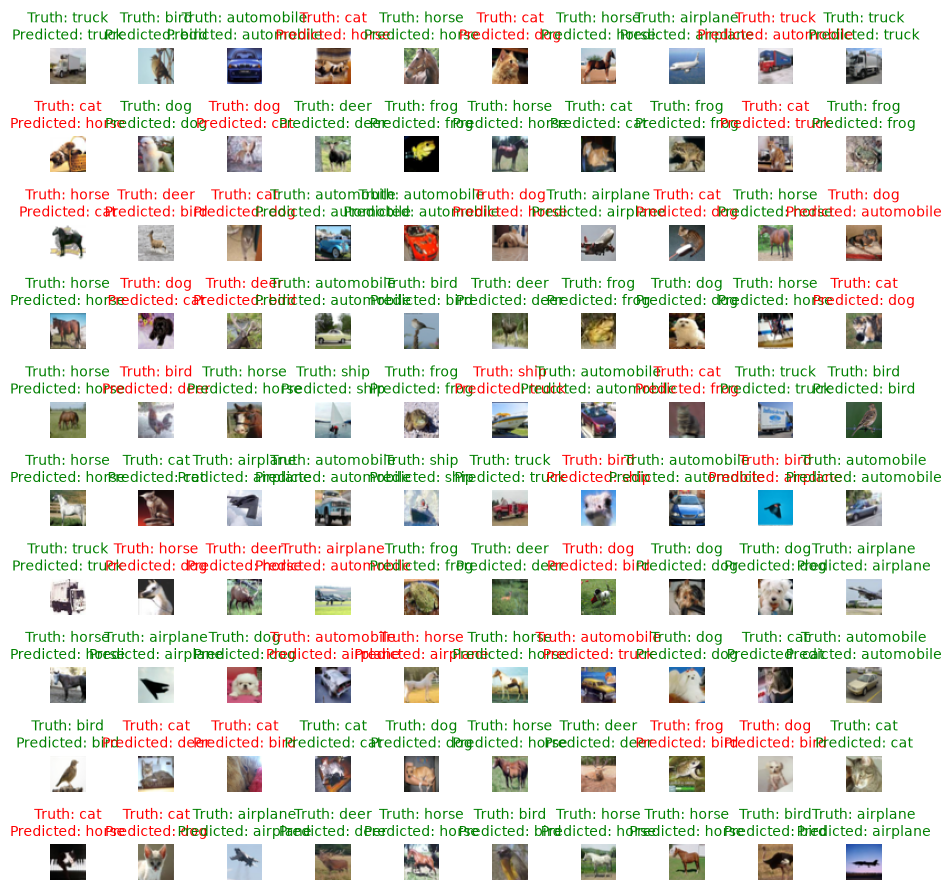

Summary: 67 correct out of 100


In [ ]:
import random
import numpy as np
def predict_and_plot_grid_quantise(model,
                          dataset,
                          classes,
                          grid_size=3):
    model.eval()
    total_images = min(grid_size * grid_size, len(dataset))
    selected_indices = random.sample(range(len(dataset)), total_images)
    correct = 0
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(9, 9))
    for image_number, idx in enumerate(selected_indices):
            i, j = divmod(image_number, grid_size)
            img, true_label = dataset[idx]
            input_tensor = img.unsqueeze(dim=0).to('cpu')
            with torch.inference_mode():
                output = model(input_tensor)
                _, predicted = torch.max(output.data, 1)
            mean = torch.tensor(cifar_mean).view(3, 1, 1)
            std = torch.tensor(cifar_std).view(3, 1, 1)
            img = (img.cpu() * std + mean).clamp(0, 1)
            npimg = img.numpy()
            axes[i, j].imshow(np.transpose(npimg, (1, 2, 0)))
            color = classes[true_label] == classes[predicted.item()]
            correct += int(color)
            if color:
                c = "g"
            else:
                c = "r"
            axes[i, j].set_title(f"Truth: {classes[true_label]}\nPredicted: {classes[predicted.item()]}", fontsize=10, c=c)
            axes[i, j].axis("off")
    for image_number in range(total_images, grid_size * grid_size):
        i, j = divmod(image_number, grid_size)
        axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Summary: {correct} correct out of {total_images}")

predict_and_plot_grid_quantise(qat_model_int8, test_data, classes=train_data.classes, grid_size=10)
